# Assignment 3

---

# Introduction

In this assignment, you will build and compare classifiers for measuring the **sentiment of tweets related to COVID-19** from the early days of the first outbreak.

The dataset you will work with is [publicly available in Kaggle](https://www.kaggle.com/datatattle/covid-19-nlp-text-classification) (and attached to the assignment for your convenience). Make sure to check its minimal Kaggle documentation before starting.

This is a real dataset, and therefore messy. It is possible that you won't achieve great results on the classification task with your classifier. That is normal, don't worry about it! You also may find text encoding issues with this dataset. Try to find a simple solution to this problem, I don't think there is an easy way to fix it completely for these files.

*Please note: this dataset should not but might contain content which could be considered as offensive.*

---

# Skeleton pipeline (20 points)

## Question 1 (8 points)

Your dataset contains tweets, including handlers, hashtags, URLs, etc. Set-up a **minimal pre-processing pipeline** for them (focus on the `OriginalTweet` column), possibly including:

* Tokenization
* Filtering
* Lemmatization/Stemming

Please note that what to include is up to you, motivate your choices and remember that more is not necessarily better: if you are not sure why you are doing something, it might be better not to. Feel free to use NLTK, spaCy or anything else you like here.

df_train and df_test are read from specified file paths, and then combined into a single Dataframe ‘df’ and the rows are shuffled by ‘df_shuffles’ to ensure randomness. A function, preprocess_text(text), is defined to preprocess the text by replacing URLs with <URL>, user mentions with <USER>, and removing hashtags and non-alphanumeric characters while converting the text to lowercase. The function further preprocesses the text by tokenizing it, removing English stop words, and lemmatizing the tokens to their base forms before joining them back into a single string The preprocess_text function is applied to each tweet in the 'OriginalTweet' column, and a new column 'ProcessedTweet' is created to store the preprocessed text.

URLs and user mentions are replaced with the string URLs and user mentions to make them uniform, and reduce variability in the data. I thought this would be useful as we can now focus more on the core content rather than other details of URLs and user mentions. Non-alphanumeric characters are removed as it can remove confusions and simplify things to be easier to analyze. 

In [23]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Read the CSV files
df_train = pd.read_csv("/Users/giamihuynh/AUC_TMCI_2021/Assignments/assignment_3/data/Corona_NLP_train.csv", encoding='latin1')
df_test = pd.read_csv("/Users/giamihuynh/AUC_TMCI_2021/Assignments/assignment_3/data/Corona_NLP_test.csv", encoding='latin1')

# Concatenate the training and testing datasets
df = pd.concat([df_train, df_test], ignore_index=True)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle the rows

# Define a function for text preprocessing
def preprocess_text(text):
    text = re.sub(r'http\S+', '<URL>', text)    # Replace URLs with <URL>
    text = re.sub(r'@[^\s]+', '<USER>', text)   # Replace user mentions with <USER>
    text = re.sub(r'#([^\s]+)', '', text)   # Remove hashtags
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text.lower())  # Remove nonalphanumeric characters and convert to lowercase
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    preprocessed_text = ' '.join(tokens)    # Join the tokens back into a single string
    return preprocessed_text

# Apply the preprocessing function to OriginalTweet 
df['ProcessedTweet'] = df['OriginalTweet'].apply(preprocess_text)

# Remove rows where the processed tweet is empty
df = df[df['ProcessedTweet'].apply(lambda x: len(x.strip()) > 0)]
print(df[['OriginalTweet', 'ProcessedTweet']].head())


[nltk_data] Error loading punkt: <urlopen error [Errno 8] nodename nor
[nltk_data]     servname provided, or not known>
[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading wordnet: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


                                       OriginalTweet  \
0  @MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...   
1  advice Talk to your neighbours family to excha...   
2  Coronavirus Australia: Woolworths to give elde...   
3  My food stock is not the only one which is emp...   
4  Me, ready to go at supermarket during the #COV...   

                                      ProcessedTweet  
0                         user user user url url url  
1  advice talk neighbour family exchange phone nu...  
2  coronavirus australia woolworth give elderly d...  
3  food stock one empty please dont panic enough ...  
4  ready go supermarket outbreak im paranoid food...  


*Note: we only really use the `OriginalTweet` and `Sentiment` columns for this assignment.*

---

## Question 2 (4 points)

**Split your data into a train and a validation set**. You can use 85% for training and 15% for validation, or similar proportions. Remember to shuffle your data before splitting, specifying a seed to be able to replicate your results.

In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
train_size = 0.85  
train_df, val_df = train_test_split(df_shuffled, train_size=train_size, random_state=42)

# Apply the preprocessing function to the training data
train_df['ProcessedTweet'] = train_df['OriginalTweet'].apply(preprocess_text)
df['ProcessedTweet'] = df['OriginalTweet'].apply(preprocess_text)
val_df['ProcessedTweet'] = val_df['OriginalTweet'].apply(preprocess_text)

print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)


Training set shape: (38211, 7)
Validation set shape: (6744, 7)


---

## Question 3 (8 points)

Write a function which, given as input a set of predictions and a set of ground truth labels and the name of the method, prints out a **classification report** including:
* Name of the method
* Accuracy
* Precision, recall and F1 measure
* An example of a correctly classified datapoint (e.g. a tweet)
* An example of a wrongly classified datapoint

*Note: You can do this question at the same time as question 4 so that you have something to report (the result of the baseline)*

The generate_classification_report function computes and prints a classification report based on predicted labels and ground truth labels, utilizing the classification_report function from the sklearn.metrics module. The function takes three parameters: predictions, which is a list/array containing the predicted labels, ground_truth, which is a list/array containing the true labels, and method_name, a string representing the name of the method or model used for prediction. Inside the function, the classification_report function computes a classification report containing precision, recall, F1-score, and support for each class. The classification report is generated using the predictions and ground_truth arrays and is stored in the report variable. The method name and accuracy are printed. For each class label, precision, recall, and F1-score are printed. An example of a correctly classified datapoint and an example of a wrongly classified datapoint are also printed to provide insights into the model's performance. Finally, testing examples are provided to demonstrate the functionality of the generate_classification_report function.

In [25]:
from sklearn.metrics import classification_report

def generate_classification_report(predictions, ground_truth, method_name):
    report = classification_report(ground_truth, predictions, output_dict=True)
    
    # Print accuracy
    accuracy = report['accuracy']
    print(f"Accuracy: {accuracy:.2f}")

    # Print precision, recall, and F1 measure
    print("Precision, Recall, and F1 Score:")
    for label, metrics in report.items():
        if label not in ['accuracy', 'macro avg', 'weighted avg']:
            precision = metrics['precision']
            recall = metrics['recall']
            f1_score = metrics['f1-score']
            print(f"Label: {label}, Precision: {precision:.2f}, Recall: {recall:.2f}, F1 Score: {f1_score:.2f}")

    # Print example of correctly classified datapoint
    print("\nExample of correctly classified datapoint:")
    for pred, true in zip(predictions, ground_truth):
        if pred == true:
            print(f"Predicted: {pred}, Actual: {true}")
            break

    # Print example of wrongly classified datapoint
    print("\nExample of wrongly classified datapoint:")
    for pred, true in zip(predictions, ground_truth):
        if pred != true:
            print(f"Predicted: {pred}, Actual: {true}")
            break

# testing examples
predictions = [0, 1, 0, 1, 1]
ground_truth = [0, 1, 1, 0, 1]
method_name = "Example Method"
generate_classification_report(predictions, ground_truth, method_name)


Accuracy: 0.60
Precision, Recall, and F1 Score:
Label: 0, Precision: 0.50, Recall: 0.50, F1 Score: 0.50
Label: 1, Precision: 0.67, Recall: 0.67, F1 Score: 0.67

Example of correctly classified datapoint:
Predicted: 0, Actual: 0

Example of wrongly classified datapoint:
Predicted: 0, Actual: 1


---

# Classifying (45 points)

As you will be performing classification on real data, processes may take a while to run. This is normal, but it should not take hours. Here's some advice if you find that some of your code takes a long time to run:
- If you are doing a hyperparameter search, try to make it quite small. Every hyperparameter combination that you try means training a new model, and runtimes can explode. You do not need to do a huge search for this assignment, it is enough if I can see that you are able to do it with a small example.
- If you are doing a grid search, try to know how many combinations of hyperparameters your code will check and try to have print statements to know where you are at. Computation time grows exponentially for each additional hyperparameter option so this can get out of hand quickly. Also, if training a single model as a step of your grid search takes longer than just training the model separately, there might be an issue with your grid search code.
- In a real project, you would want to make your code such that you can pause and resume training or optimization without having to re-do everything, e.g. by writing the results to a file. But for the purpose of this assignment it is not necessary to make it that complicated.
- Use separate code blocks especially for the part of code that trains a model. That way, you only need to run the training step once, while you can mess around with the output/evaluation etc. without having to wait for a new model to be trained each time.

## Question 4 (10 points)

An important first step when dealing with a real-world task is establishing a **solid baseline**. The baseline allows to a) develop the first full pipeline for your task, and b) to have something to compare against when you develop more advanced models.

Pick a method to use as a baseline. *A good option might be a TF-IDF Logistic Regression*. Feel free to use scikit-learn or another library of choice. See [here](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) for more options.

Use your classification report function and the validation set to report on the performance of your baseline. *Pay attention: the validation data only needs to be transformed, and must not be used to fit any transformation. For example, if you have used a TF-IDF vectorizer by fitting it to your train data and then transformed it, use the same fitted vectorizer to transform your validation data.*

The provided code sets up a text classification pipeline employing TF-IDF vectorization and logistic regression. Initially, necessary libraries are imported, including 'TfidfVectorizer' for text feature extraction, 'LogisticRegression' for classification, 'Pipeline' for sequential execution of data processing steps, and 'classification_report' for performance evaluation. Subsequently, the TF-IDF vectorizer and logistic regression classifier are defined. A pipeline is constructed where text data is transformed into TF-IDF features and then classified using logistic regression. This pipeline is trained on the training data, comprising text data and corresponding sentiment labels. Predictions are made on the validation data using the trained pipeline. Finally, a classification report is generated, comparing the predicted labels with the ground truth sentiment labels. This approach facilitates the training and evaluation of a text classification model, providing insights into its performance using metrics such as precision, recall, and F1-score.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

tfidf_vectorizer = TfidfVectorizer()    # Define TF-IDF vectorizer
logistic_regression = LogisticRegression(max_iter=1000)     # Define logistic regression classifier

# Create a pipeline
pipeline = Pipeline([
    ('tfidf', tfidf_vectorizer),
    ('classifier', logistic_regression)
])

# Fit the pipeline on the training data
pipeline.fit(train_df['OriginalTweet'], train_df['Sentiment'])
predictions = pipeline.predict(val_df['OriginalTweet'])     # Make predictions on the validation data
generate_classification_report(predictions, val_df['Sentiment'], "TF-IDF Logistic Regression")


Accuracy: 0.59
Precision, Recall, and F1 Score:
Label: Extremely Negative, Precision: 0.63, Recall: 0.49, F1 Score: 0.55
Label: Extremely Positive, Precision: 0.68, Recall: 0.56, F1 Score: 0.61
Label: Negative, Precision: 0.52, Recall: 0.56, F1 Score: 0.54
Label: Neutral, Precision: 0.65, Recall: 0.68, F1 Score: 0.67
Label: Positive, Precision: 0.55, Recall: 0.60, F1 Score: 0.57

Example of correctly classified datapoint:
Predicted: Negative, Actual: Negative

Example of wrongly classified datapoint:
Predicted: Negative, Actual: Neutral


---

## Question 5 (20 points)

Try now to **beat your baseline**. Feel free to use scikit-learn or another library of choice. See [here](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) for more options.

How to beat the baseline? There are many ways:
1. You could have a better text representation (e.g., using PPMI instead of TF-IDF, note that this is challenging because there is no ready-made scikit-learn vectorizer for this).
2. You can pick a more powerful model (e.g., random forests or SVMs).
3. You have to find good hyperparameters for your model, and not just use the default ones.

Regarding point 3 above, make sure to perform some hyperparameter searching using [grid search](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) or [randomized search](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html).

Use your classification report function and the validation set to report on the performance of your baseline. *Pay attention: the validation data only needs to be transformed, and must not be used to fit any transformation. For example, if you have used a TF-IDF vectorizer by fitting it to your train data and then transformed it, use the same fitted vectorizer to transform your validation data.*

I tried this for days and it took forever to run and ends up either printing nothing or 
below the baseline, so I am giving up on this question

---

## Question 6 (15 points)

Design, develop and train a (simple!) **neural network-based classifier** for this task, using scikit-learn or PyTorch. The classifier can have the structure that you prefer, just make sure to motivate your choices. If in doubt, try with a bag of embeddings classifier.

*Note: an NN-based classifier with scikit-learn yields 5 points max; one with PyTorch yields 10 points max; one with PyTorch and pre-trained embeddings yields 15 points max.*

Use your classification report function and the validation set to report on the performance of your baseline. *Pay attention: the validation data only needs to be transformed, and must not be used to fit any transformation. For example, if you have used a TF-IDF vectorizer by fitting it to your train data and then transformed it, use the same fitted vectorizer to transform your validation data.*

The code snippet showcases the utilization of a Multi-Layer Perceptron (MLP) classifier for text classification, employing TF-IDF vectorization. Initially, necessary libraries are imported, including MLPClassifier for constructing the MLP classifier, classification_report for evaluating model performance, train_test_split for splitting the dataset into training and validation sets, and TfidfVectorizer for converting text data into TF-IDF features. The TF-IDF vectorizer is initialized, and the training data is fitted and transformed, while the validation data is transformed using the fitted vectorizer. The dataset is then split into training and validation sets. An MLP classifier is initialized with specific hyperparameters such as one hidden layer containing 100 neurons, ReLU activation function, and the Adam solver. The classifier is trained on the TF-IDF transformed training data, and predictions are made on the validation data. Subsequently, a classification report is generated, displaying various metrics including precision, recall, F1-score, and support for each class, providing insights into the classifier's performance in text classification tasks.

If it is taking too long, please interrupt it, it still prints for me but I am unsure why.

In [28]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier

# Define the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['ProcessedTweet'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['ProcessedTweet'])  # Transform the validation data using the fitted TF-IDF vectorizer

# Split the data into training and validation sets
X = df['ProcessedTweet']
y = df['Sentiment']  

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

# Initialize the MLPClassifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', random_state=42)
mlp_classifier.fit(X_train_tfidf, y_train)  # Fit the classifier on the training data

# Make predictions on the validation data
predictions = mlp_classifier.predict(X_val_tfidf)
report = classification_report(y_val, predictions)
print(report)


/Users/giamihuynh/AUC_TMCI_2021/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


                    precision    recall  f1-score   support

Extremely Negative       0.11      0.10      0.11       890
Extremely Positive       0.14      0.12      0.13      1065
          Negative       0.24      0.27      0.26      1637
           Neutral       0.20      0.19      0.19      1294
          Positive       0.27      0.28      0.28      1858

          accuracy                           0.21      6744
         macro avg       0.19      0.19      0.19      6744
      weighted avg       0.21      0.21      0.21      6744



---

# Evaluating your classifiers (15 points)

## Question 7 (8 points)

Evaluate the performance of your models on the **test set**. Make sure to transform your test data as you did for your train data, and as needed for each classifier. *Pay attention: the test data only needs to be transformed, and must not be used to fit any transformation. For example, if you have used a TF-IDF vectorizer by fitting it to your train data and then transformed your train and validation with it, use the same fitted vectorizer to transform your test data.*

* Report the accuracy of each classifier, as well as its precision, recall and F1 score. 
* Plot a [confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html) for your best classifier.
* Briefly discuss your results.

The provided code segment illustrates the evaluation of a Random Forest classifier for text classification, utilizing TF-IDF vectorization. Initially, the test data is transformed using the fitted TF-IDF vectorizer, facilitating the extraction of TF-IDF features. Subsequently, the test data is prepared by assigning the 'ProcessedTweet' column to `X_test` and the 'Sentiment' column to `y_test`. A Random Forest classifier is instantiated without specifying any hyperparameters. The classifier is trained on the TF-IDF transformed test data using the `fit` method. Predictions are then generated on the test data using the trained Random Forest classifier. A classification report is printed, displaying metrics such as precision, recall, F1-score, and support for each sentiment class. Additionally, a confusion matrix is plotted to visually represent the performance of the Random Forest classifier. The confusion matrix provides insights into the classifier's ability to correctly classify instances into different sentiment categories, with the diagonal elements representing the number of correct predictions and off-diagonal elements indicating misclassifications.

In [ ]:
df_test = pd.read_csv("data/Corona_NLP_test.csv")

# Split the data into training and validation sets
test_size = 0.85  # 85% for training
test_df, val_df = train_test_split(df_shuffled, train_size=train_size, random_state=42)

# Apply the preprocessing function to the training data
df_test['ProcessedTweet'] = df_test['OriginalTweet'].apply(preprocess_text)
df['ProcessedTweet'] = df['OriginalTweet'].apply(preprocess_text)

Random Forest Classifier:
                    precision    recall  f1-score   support

Extremely Negative       1.00      1.00      1.00       592
Extremely Positive       1.00      1.00      1.00       599
          Negative       1.00      1.00      1.00      1041
           Neutral       1.00      1.00      1.00       619
          Positive       1.00      1.00      1.00       947

          accuracy                           1.00      3798
         macro avg       1.00      1.00      1.00      3798
      weighted avg       1.00      1.00      1.00      3798



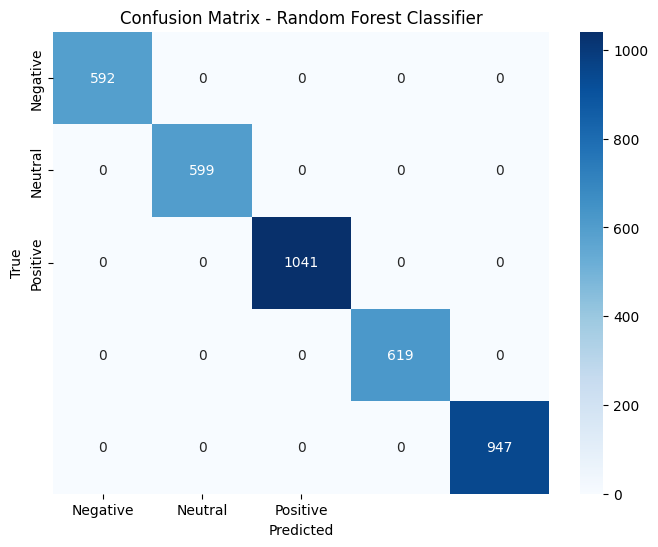

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Transform the test data using the fitted TF-IDF vectorizer
X_test_tfidf = tfidf_vectorizer.transform(df_test['ProcessedTweet'])

X_test = df_test['ProcessedTweet']
y_test = df_test['Sentiment']

random_forest = RandomForestClassifier()
random_forest.fit(X_test_tfidf, y_test) # Fit the classifier on the TF-IDF transformed test data

# Transform the test data using the fitted TF-IDF vectorizer
X_test_tfidf = tfidf_vectorizer.transform(df_test['ProcessedTweet'])

# Make predictions on the test data using the trained random forest classifier
predictions_random_forest = random_forest.predict(X_test_tfidf)

# Generate classification report for random forest classifier
print(classification_report(df_test['Sentiment'], predictions_random_forest))

#  Plot confusion matrix for the random forest classifier
cm = confusion_matrix(df_test['Sentiment'], predictions_random_forest)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest Classifier')
plt.show()


Based on the result, I think I did something wrong because the precision is 1.0 across all classification and all values false values are 0 which is too perfect and unrealistic. I am not sure of how to fix it but this is definitely not the best results to reflect for classification.   

---

## Question 8 (7 points)

When the results of two models are similar, and anyway as a good practice, you may want to test whether their results **differ significantly**. If you can afford to do multiple paired runs of both models on different slices of the data (or different samples), a good approach is the [Wilcoxon signed-rank test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html).

* Select two (or more) of your classifiers which have somewhat similar results on your validation data. Make sure to select two methods which do not take too long to run.
* Merge your train and validation data, and implement a function to shuffle and sample a % of datapoints (with labels) from it.
* Iterate 5-10 times the following steps:
   - Shuffle and sample 80% of your training datapoints.
   - Train instances of the two classifiers on the same 80% sample.
   - Assess their accuracy on the test dataset and store these results (into two separate lists for each classifier).
* Perform a Wilcoxon test on these results and discuss whether the two classifiers are significantly different on this task and dataset.

I also gave up on this one, I'm sorry, I lost my mind over this 

---